# Category Stats

In [14]:
import pandas as pd
import numpy as np

In [15]:
original_df = pd.read_csv("tmdb_reviews_labeled.csv")
null_categories = original_df['category'].isna().sum()
empty_categories = (original_df['category'] == '').sum()
print(f"\n\nRows with NaN categories: {null_categories}")
print(f"Rows with empty categories: {empty_categories}")



Rows with NaN categories: 0
Rows with empty categories: 0


In [16]:
categories_split = original_df['category'].str.split(', ').explode()

# Get unique categories and their count
unique_categories = categories_split.unique()
num_unique_categories = len(unique_categories)
category_counts = categories_split.value_counts()

print(f"Total number of unique categories: {num_unique_categories}")
print("\nUnique categories:")
for i, category in enumerate(sorted(unique_categories), 1):
    print(f"{i}. {category}: {category_counts[category]}")

Total number of unique categories: 19

Unique categories:
1. Action: 2396
2. Adventure: 1842
3. Animation: 460
4. Comedy: 1082
5. Crime: 701
6. Documentary: 4
7. Drama: 1261
8. Family: 547
9. Fantasy: 839
10. History: 169
11. Horror: 880
12. Music: 68
13. Mystery: 409
14. Romance: 378
15. Science Fiction: 1501
16. TV Movie: 3
17. Thriller: 1475
18. War: 148
19. Western: 53


## Test Dataset Category Check

In [25]:
test_df = pd.read_csv("output/svm_predictions_tfidf_cleaned.csv")

categories_split = test_df['category'].str.split(', ').explode()

# Get unique categories and their count
unique_categories = categories_split.unique()
num_unique_categories = len(unique_categories)
category_counts = categories_split.value_counts()

print(f"Total number of unique categories in test dataset: {num_unique_categories}")
print("\nUnique categories in test dataset:")
for i, category in enumerate(sorted(unique_categories), 1):
    print(f"{i}. {category}: {category_counts[category]}")

Total number of unique categories in test dataset: 18

Unique categories in test dataset:
1. Action: 572
2. Adventure: 435
3. Animation: 113
4. Comedy: 276
5. Crime: 186
6. Documentary: 1
7. Drama: 323
8. Family: 138
9. Fantasy: 192
10. History: 38
11. Horror: 233
12. Music: 18
13. Mystery: 105
14. Romance: 99
15. Science Fiction: 362
16. Thriller: 375
17. War: 28
18. Western: 18


# Classifying data with HuggingFace Model

In [ ]:
from transformers import pipeline

In [19]:
# Load DistilBERT model
print("Loading DistilBERT model...")
distilbert = pipeline('text-classification', 
                      model='distilbert-base-uncased-finetuned-sst-2-english',
                      device=-1)  # Use -1 for CPU, 0 for GPU if available

print("Model loaded successfully!")

Loading DistilBERT model...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2273.05it/s]


Model loaded successfully!


In [ ]:
test_indices = test_df.original_dataset_indices
test_texts = original_df.loc[test_indices, "review"]

# Make predictions with DistilBERT
distilbert_preds = []
for text in test_texts:  # Replace 'test_texts' with your actual test text data
    result = distilbert(text, truncation=True, max_length=512)[0]
    distilbert_preds.append(result)

# Convert to numpy array
distilbert_preds = np.array(distilbert_preds)

In [28]:
distilbert_preds

array([{'label': 'POSITIVE', 'score': 0.9996306896209717},
       {'label': 'NEGATIVE', 'score': 0.9997848868370056},
       {'label': 'POSITIVE', 'score': 0.9673596024513245}, ...,
       {'label': 'POSITIVE', 'score': 0.9992269277572632},
       {'label': 'NEGATIVE', 'score': 0.949874758720398},
       {'label': 'POSITIVE', 'score': 0.9196087121963501}],
      shape=(1249,), dtype=object)

# Combining Results

In [44]:
distilbert_preds = [pred.lower() if isinstance(pred, str) else pred['label'].lower() for pred in distilbert_preds]
distilbert_preds

['positive',
 'negative',
 'positive',
 'negative',
 'positive',
 'negative',
 'negative',
 'negative',
 'positive',
 'negative',
 'negative',
 'negative',
 'positive',
 'positive',
 'positive',
 'positive',
 'positive',
 'negative',
 'negative',
 'negative',
 'negative',
 'positive',
 'positive',
 'positive',
 'positive',
 'positive',
 'negative',
 'negative',
 'positive',
 'positive',
 'positive',
 'negative',
 'positive',
 'negative',
 'negative',
 'negative',
 'negative',
 'negative',
 'positive',
 'negative',
 'negative',
 'positive',
 'positive',
 'negative',
 'positive',
 'negative',
 'negative',
 'negative',
 'negative',
 'positive',
 'negative',
 'positive',
 'negative',
 'negative',
 'positive',
 'positive',
 'positive',
 'positive',
 'negative',
 'negative',
 'negative',
 'negative',
 'negative',
 'positive',
 'negative',
 'positive',
 'negative',
 'negative',
 'negative',
 'negative',
 'negative',
 'positive',
 'positive',
 'negative',
 'negative',
 'negative',
 'negative',

In [45]:
comparison_df = test_df.copy()
comparison_df["sota_pred"] = distilbert_preds

In [46]:
comparison_df_without_neutral = comparison_df[
    (comparison_df['sentiment'] != 'neutral') & 
    (comparison_df['svm_pred'] != 'neutral')
].copy()

In [50]:
comparison_df_without_neutral

,original_dataset_indices,category,sentiment,svm_pred,sota_pred
0,84,"Drama, Western",positive,positive,positive
2,1497,"Comedy, Animation, Family",negative,negative,positive
5,4879,"Drama, Comedy",negative,negative,negative
6,157,"Thriller, Action",negative,negative,negative
7,3611,Western,positive,negative,negative
...,...,...,...,...,...
1242,4611,"Fantasy, Horror, Action",negative,negative,negative
1244,2321,"Science Fiction, Adventure",negative,negative,negative
1245,4880,"Science Fiction, Adventure",positive,positive,negative
1246,2846,"Crime, Drama, Action",positive,positive,positive


# Begin the category split process and calculate metrics

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
from collections import defaultdict

In [48]:
# Split and explode categories
df_exploded = comparison_df_without_neutral.copy()

# Split by comma and space, then explode
df_exploded['category'] = df_exploded['category'].str.split(', ')
df_exploded = df_exploded.explode('category')

# Strip any whitespace
df_exploded['category'] = df_exploded['category'].str.strip()

print(f"Original rows: {len(comparison_df_without_neutral)}")
print(f"Rows after exploding categories: {len(df_exploded)}")
print(f"Unique categories: {df_exploded['category'].nunique()}")
df_exploded

Original rows: 686
Rows after exploding categories: 1926
Unique categories: 17


,original_dataset_indices,category,sentiment,svm_pred,sota_pred
0,84,Drama,positive,positive,positive
0,84,Western,positive,positive,positive
2,1497,Comedy,negative,negative,positive
2,1497,Animation,negative,negative,positive
2,1497,Family,negative,negative,positive
...,...,...,...,...,...
1246,2846,Drama,positive,positive,positive
1246,2846,Action,positive,positive,positive
1247,490,Action,positive,positive,negative
1247,490,Adventure,positive,positive,negative


In [49]:
def calculate_category_metrics(df, true_col, pred_col):
    categories = df['category'].unique()
    results = {}
    
    for category in categories:
        # Filter data for this category
        cat_data = df[df['category'] == category]
        
        # Get true and predicted labels
        y_true = cat_data[true_col]
        y_pred = cat_data[pred_col]
        
        # Calculate metrics
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        
        results[category] = {
            'accuracy': acc,
            'f1_score': f1,
            'samples': len(cat_data)
        }
    
    return results

svm_metrics = calculate_category_metrics(df_exploded, 'sentiment', 'svm_pred')
sota_metrics = calculate_category_metrics(df_exploded, 'sentiment', 'sota_pred')

In [51]:
# Create DataFrame with results
results_df = pd.DataFrame({
    'category': list(svm_metrics.keys()),
    'svm_accuracy': [svm_metrics[cat]['accuracy'] for cat in svm_metrics.keys()],
    'svm_f1': [svm_metrics[cat]['f1_score'] for cat in svm_metrics.keys()],
    'sota_accuracy': [sota_metrics[cat]['accuracy'] for cat in sota_metrics.keys()],
    'sota_f1': [sota_metrics[cat]['f1_score'] for cat in sota_metrics.keys()],
    'sample_count': [svm_metrics[cat]['samples'] for cat in svm_metrics.keys()]
})

# Sort by category name
results_df = results_df.sort_values('category').reset_index(drop=True)
results_df

,category,svm_accuracy,svm_f1,sota_accuracy,sota_f1,sample_count
0,Action,0.947735,0.947426,0.571429,0.571241,287
1,Adventure,0.947598,0.945084,0.576419,0.574341,229
2,Animation,0.926471,0.907180,0.573529,0.537415,68
3,Comedy,0.947712,0.947531,0.607843,0.606481,153
4,Crime,0.955752,0.955529,0.557522,0.557210,113
5,Drama,0.921951,0.921860,0.609756,0.607656,205
6,Family,0.936709,0.931388,0.582278,0.577950,79
7,Fantasy,0.922330,0.921073,0.514563,0.514517,103
8,History,0.916667,0.906250,0.541667,0.520871,24
9,Horror,0.917355,0.907774,0.578512,0.558110,121


In [52]:
# Calculate which model is better for each category
results_df['better_accuracy'] = results_df.apply(
    lambda row: 'SVM' if row['svm_accuracy'] > row['sota_accuracy'] 
                else ('SOTA' if row['sota_accuracy'] > row['svm_accuracy'] else 'Tie'),
    axis=1
)

results_df['better_f1'] = results_df.apply(
    lambda row: 'SVM' if row['svm_f1'] > row['sota_f1'] 
                else ('SOTA' if row['sota_f1'] > row['svm_f1'] else 'Tie'),
    axis=1
)
results_df

,category,svm_accuracy,svm_f1,sota_accuracy,sota_f1,sample_count,better_accuracy,better_f1
0,Action,0.947735,0.947426,0.571429,0.571241,287,SVM,SVM
1,Adventure,0.947598,0.945084,0.576419,0.574341,229,SVM,SVM
2,Animation,0.926471,0.907180,0.573529,0.537415,68,SVM,SVM
3,Comedy,0.947712,0.947531,0.607843,0.606481,153,SVM,SVM
4,Crime,0.955752,0.955529,0.557522,0.557210,113,SVM,SVM
5,Drama,0.921951,0.921860,0.609756,0.607656,205,SVM,SVM
6,Family,0.936709,0.931388,0.582278,0.577950,79,SVM,SVM
7,Fantasy,0.922330,0.921073,0.514563,0.514517,103,SVM,SVM
8,History,0.916667,0.906250,0.541667,0.520871,24,SVM,SVM
9,Horror,0.917355,0.907774,0.578512,0.558110,121,SVM,SVM


In [71]:
# Save detailed category results
results_df.to_csv('output/category_performance_analysis.csv', index=False)

# Visualize Results

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [73]:
os.makedirs('visualization_outputs', exist_ok=True)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

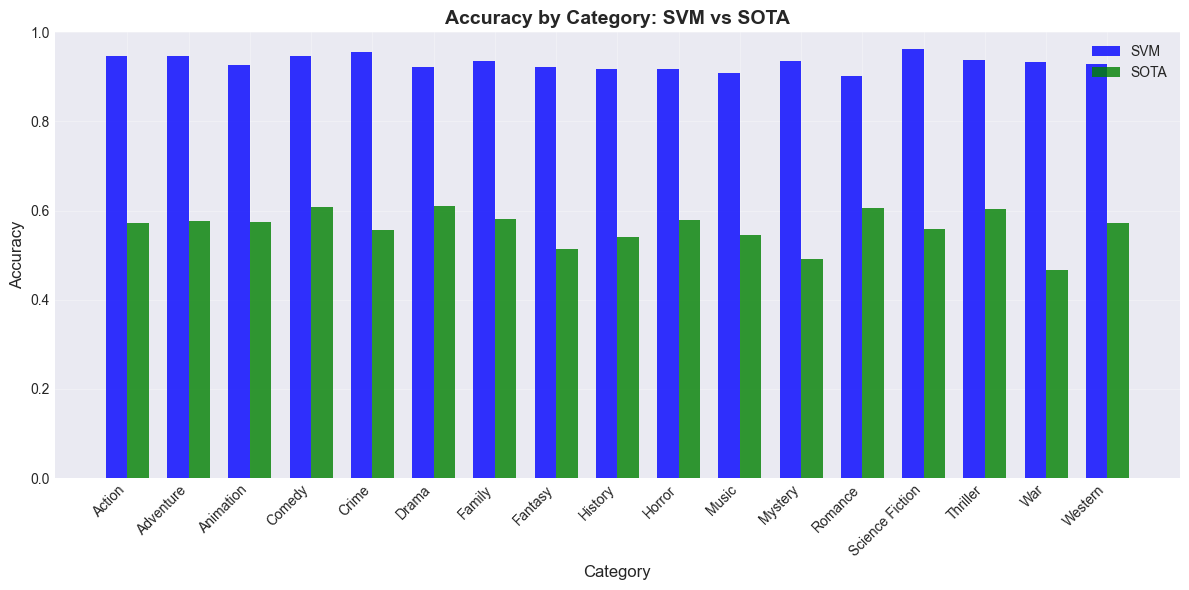

In [74]:
# 1. Accuracy Comparison by Category
fig1, ax1 = plt.subplots(figsize=(12, 6))
categories = results_df['category']
x = range(len(categories))
width = 0.35
ax1.bar([i - width/2 for i in x], results_df['svm_accuracy'], width, label='SVM', alpha=0.8, color='blue')
ax1.bar([i + width/2 for i in x], results_df['sota_accuracy'], width, label='SOTA', alpha=0.8, color='green')
ax1.set_xlabel('Category', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Accuracy by Category: SVM vs SOTA', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=45, ha='right')
ax1.legend()
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('visualization_outputs/accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('visualization_outputs/accuracy_comparison.pdf', bbox_inches='tight')  # Also save as PDF
plt.show()

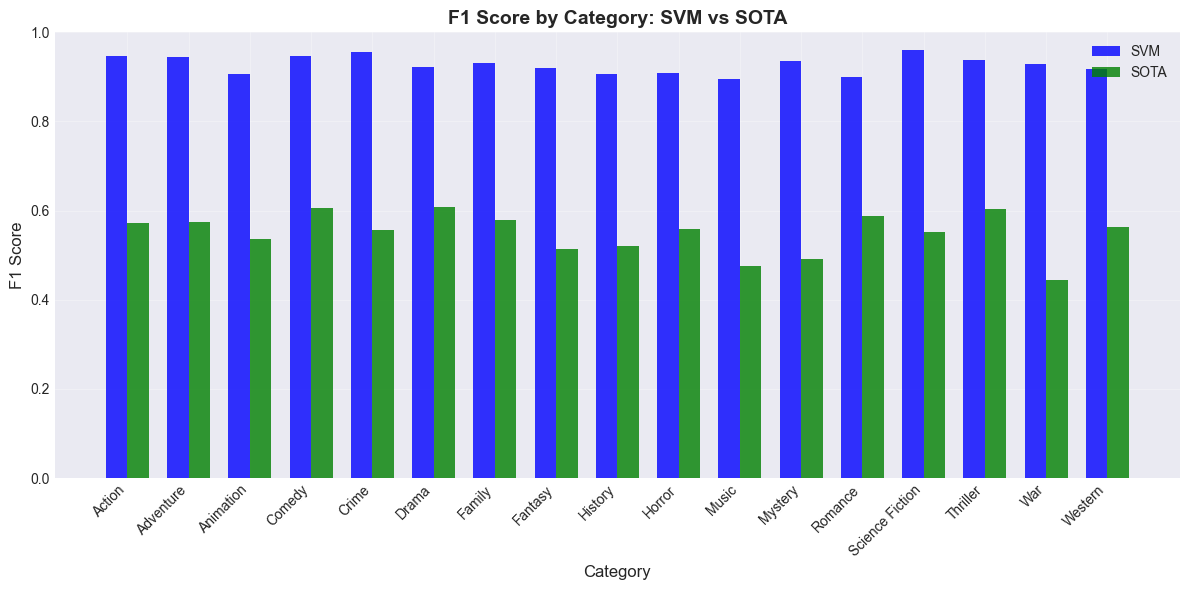

In [75]:
# 2. F1 Score Comparison by Category
fig2, ax2 = plt.subplots(figsize=(12, 6))
ax2.bar([i - width/2 for i in x], results_df['svm_f1'], width, label='SVM', alpha=0.8, color='blue')
ax2.bar([i + width/2 for i in x], results_df['sota_f1'], width, label='SOTA', alpha=0.8, color='green')
ax2.set_xlabel('Category', fontsize=12)
ax2.set_ylabel('F1 Score', fontsize=12)
ax2.set_title('F1 Score by Category: SVM vs SOTA', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(categories, rotation=45, ha='right')
ax2.legend()
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('visualization_outputs/f1_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('visualization_outputs/f1_comparison.pdf', bbox_inches='tight')
plt.show()

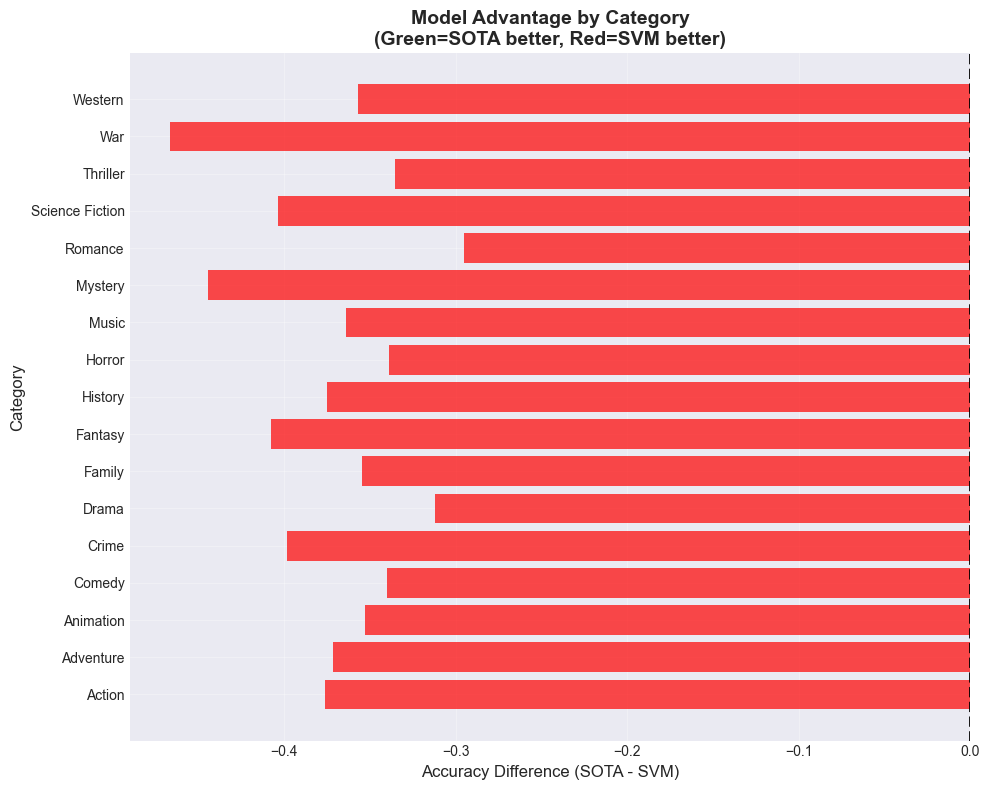

In [76]:
# 3. Difference Plot (SOTA - SVM)
fig3, ax3 = plt.subplots(figsize=(10, 8))
diff_acc = results_df['sota_accuracy'] - results_df['svm_accuracy']
colors = ['green' if d > 0 else 'red' if d < 0 else 'gray' for d in diff_acc]
ax3.barh(categories, diff_acc, color=colors, alpha=0.7)
ax3.axvline(x=0, color='black', linestyle='--', linewidth=2)
ax3.set_xlabel('Accuracy Difference (SOTA - SVM)', fontsize=12)
ax3.set_ylabel('Category', fontsize=12)
ax3.set_title('Model Advantage by Category\n(Green=SOTA better, Red=SVM better)', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('visualization_outputs/model_advantage.png', dpi=300, bbox_inches='tight')
plt.savefig('visualization_outputs/model_advantage.pdf', bbox_inches='tight')
plt.show()